In [1]:
# Cell 1 — Load from DB
import pandas as pd
import numpy as np
import sys
sys.path.append('../src')
from db_utils import get_engine

engine = get_engine()
df = pd.read_sql("SELECT * FROM raw_employees", con=engine)
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# Cell 2 — Check what needs encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
print("\nUnique values per column:")
for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Unique values per column:
  Attrition: ['Yes' 'No']
  BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
  Department: ['Sales' 'Research & Development' 'Human Resources']
  EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
  Gender: ['Female' 'Male']
  JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
  MaritalStatus: ['Single' 'Married' 'Divorced']
  Over18: ['Y']
  OverTime: ['Yes' 'No']


In [3]:
# Cell 3 — Drop useless columns
# These have zero variance or leak the target — standard practice to drop
useless = ['EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=useless, inplace=True)
print("Remaining columns:", df.shape[1])

Remaining columns: 32


In [4]:
# Cell 4 — Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print(df['Attrition'].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [5]:
# Cell 5 — Encode binary categoricals
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
print(df[['Gender', 'OverTime']].head())

   Gender  OverTime
0       0         1
1       1         0
2       1         1
3       0         1
4       1         0


In [6]:
# Cell 6 — One-hot encode multi-class categoricals
multi_cat = ['BusinessTravel', 'Department', 'EducationField',
             'JobRole', 'MaritalStatus']
df = pd.get_dummies(df, columns=multi_cat, drop_first=True)
print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (1470, 46)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,2,0,94,3,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,2,3,1,61,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,4,1,92,2,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,5,4,0,56,3,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,7,1,1,40,3,...,False,True,False,False,False,False,False,False,True,False


In [7]:
# Cell 7 — Feature scaling
from sklearn.preprocessing import StandardScaler

# These are the numeric columns that need scaling for some models
scale_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
              'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
              'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
              'YearsAtCompany', 'YearsInCurrentRole',
              'YearsSinceLastPromotion', 'YearsWithCurrManager']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])
print("Scaling done.")
df_scaled[scale_cols].describe().round(2)

Scaling done.


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.07,-1.74,-1.01,-1.77,-1.17,-1.72,-1.08,-1.15,-1.45,-2.17,-1.14,-1.17,-0.68,-1.16
25%,-0.76,-0.84,-0.89,-0.88,-0.76,-0.88,-0.68,-0.88,-0.68,-0.62,-0.65,-0.62,-0.68,-0.60
50%,-0.10,-0.00,-0.27,0.01,-0.34,-0.01,-0.28,-0.33,-0.16,0.16,-0.33,-0.34,-0.37,-0.31
75%,0.67,0.88,0.59,0.88,0.40,0.86,0.52,0.76,0.48,0.16,0.33,0.76,0.25,0.81
max,2.53,1.73,2.44,1.68,2.87,1.78,2.53,2.68,3.69,2.48,5.39,3.80,3.98,3.61


In [8]:
# Cell 8 — Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

X = df_scaled.drop(columns=['Attrition', 'EmployeeNumber'])
y = df_scaled['Attrition']

print("Before SMOTE:", y.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {0: 1233, 1: 237}
After SMOTE: {1: 1233, 0: 1233}


C:\Users\HARSHAL\AppData\Local\Temp\ipykernel_3920\3487196555.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='YlOrRd')


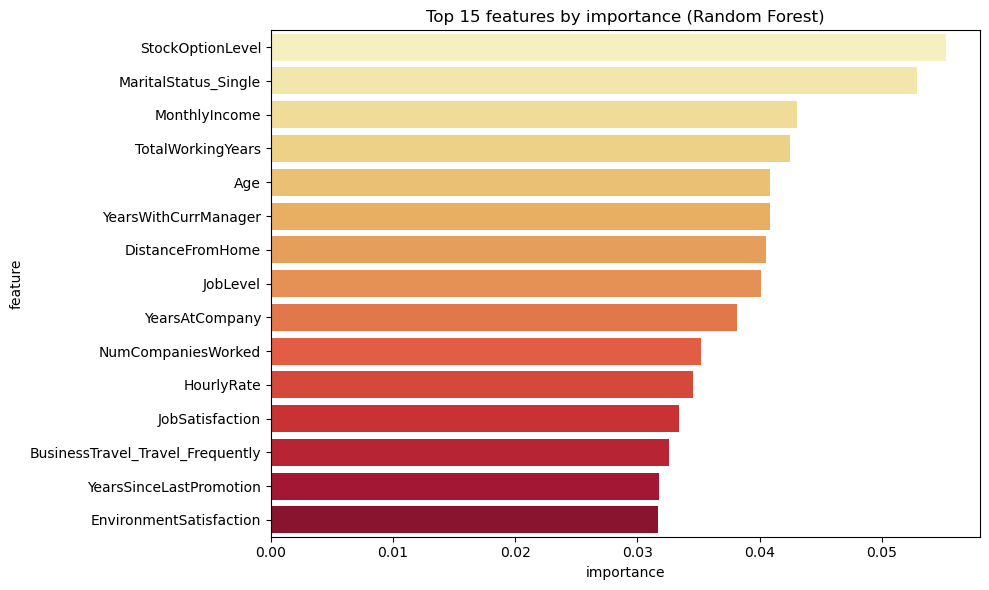

In [9]:
# Cell 9 — Quick feature importance check (before we even model)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_resampled, y_resampled)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='YlOrRd')
plt.title('Top 15 features by importance (Random Forest)')
plt.tight_layout()
plt.savefig('../data/feature_importance_preview.png', dpi=150)
plt.show()

In [11]:
!pip install imbalanced-learn